# Analysis of SCoV2 % expression

In [1]:
setwd("/scratch_isilon/groups/singlecell/shared/projects/covid-pascual-reguant")

## Libraries

In [2]:
library(here)
library(glue)
library(tidyverse)
library(patchwork)
library(cowplot)
library(Seurat)
library(SpatialExperiment)
library(HDF5Array)
library(scater)
library(viridis)
library(scran)
library(ComplexHeatmap)
library(circlize)
library(svglite)

here() starts at /scratch_isilon/groups/singlecell/shared/projects/covid-pascual-reguant

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘cowplot’


The following object is masked from ‘package:patchwork’:

    align_plots


The following object is masked from ‘package:lubridate’:

    stamp


Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t


Loading required package: S

## Load data

In [3]:
load_spe <- function(dir_name) {
    spe <- loadHDF5SummarizedExperiment(dir = here(glue("~/SP-COVID/visium/0-processing/out/{dir_name}")))
    rownames(spatialCoords(spe)) <- paste(colData(spe)$cond_tissue, rownames(spatialCoords(spe)), sep = "_")
    colnames(spe) <- paste(colData(spe)$cond_tissue, colnames(spe), sep = "_")
    return(spe)

}

load_deconv_mat <- function(tissue) {
    mat_filtered <- readRDS(here(glue("~/SP-COVID/visium/1-deconvolution/out/mat_filtered_{tissue}.rds")))
    return(mat_filtered)
}

spe_lung <- load_spe("3-annot_lung_spe")
spe_ln <- load_spe("3-annot_ln_spe")

mat_filtered_lung <- load_deconv_mat("lung")
mat_filtered_ln <- load_deconv_mat("ln")

se <- "~/SP-COVID/snRNAseq/0-annotation/out/se_annot_filtered.rds" %>%
    readRDS(.)
sce <- as.SingleCellExperiment(se)
sce

class: SingleCellExperiment 
dim: 38720 31757 
metadata(0):
assays(2): counts logcounts
rownames(38720): WASH7P AL627309.1 ... RAB9AP5 MT-TR
rowData names(0):
colnames(31757): O325-akut_GGTTGTAGTACTTCCC-1
  O325-akut_GAAGGACAGAGCCATG-1 ... T188-R2-prolonged_GGAGGATCAGTCTACA-1
  T188-R2-prolonged_TCATGGAAGGGATCAC-1
colData names(71): orig.ident nCount_RNA ... annotation ident
reducedDimNames(3): PCA HARMONY UMAP
mainExpName: RNA
altExpNames(1): integrated

## snRNA-seq

In [4]:
covid_genes <- grepl("^SCoV2|SARS2", rownames(sce))
covid_reads <- Matrix::colSums(counts(sce)[covid_genes, , drop = FALSE])

colData(sce)$covid_reads <- covid_reads
df <- as.data.frame(colData(sce))
df <- df %>%
mutate(infected = case_when(covid_reads >= 5 ~ "SCoV2_pos",
                            covid_reads > 0 ~ "SCoV2_low",
                            TRUE ~ "SCoV2_neg"))

In [5]:
df %>%
    group_by(condition) %>%
    summarise(n_infected = sum(covid_reads >= 5),
              n_total = n(),
              .groups = "drop") %>%
    mutate(fraction = round(n_infected / n_total, 2))

table(df$infected,df$orig.ident)
cat("\n\n\n")
table(df$infected, df$annotation)
cat("\n\n\n")
by(df$covid_reads[df$covid_reads >= 5], list(df$orig.ident[df$covid_reads >= 5]), summary)
cat("\n\n\n")
by(df$covid_reads[df$covid_reads >= 5], list(df$annotation[df$covid_reads >= 5]), summary)

condition,n_infected,n_total,fraction
<chr>,<int>,<int>,<dbl>
akut,183,4597,0.04
chronic,0,8006,0.00
control,0,7903,0.00
prolonged,0,11251,0.00


           
            17B-control A333-chronic A344-R3-chronic A592-prolonged
  SCoV2_low           5           27              14             25
  SCoV2_neg        1853         5574            2391           3314
  SCoV2_pos           0            0               0              0
           
            BB73-control O325-akut T128-akut T188-R2-prolonged
  SCoV2_low           30       173       185                21
  SCoV2_neg         6015      3026      1030              7891
  SCoV2_pos            0        65       118                 0

           
            AdvF Aerocytes AlvF Anti-inflammatory Macrophages Arterial ECs  AT1
  SCoV2_low   44         4   13                            12           12   53
  SCoV2_neg 1564      1553 1262                          4049          934 3704
  SCoV2_pos    8         3    2                             0            4   67
           
             AT2 B cells Basal cells Ciliated cells Club cells gCaps
  SCoV2_low   70       0          12              7         17    16
  SCoV2_neg 2688      36         459           1189        608  4033
  SCoV2_pos   14       0           1              3          1     0
           
            Inflammatory Macrophages Lymphatic ECs Mast cells Monocytes
  SCoV2_low                       14            13          0         2
  SCoV2_neg                     1382           781         29      1329
  SCoV2_pos                        0             3          0         0
           
            NK cells  PCs Pericytes Phagocytic macrophages  SMC T ce

: O325-akut
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
    5.0    11.0    34.0   242.5   220.0  4281.0 
------------------------------------------------------------ 
: T128-akut
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   5.00    7.00   17.00   54.06   41.25  665.00 

: AdvF
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   5.00    6.00   10.00   36.12   13.25  225.00 
------------------------------------------------------------ 
: Aerocytes
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   17.0    24.5    32.0    53.0    71.0   110.0 
------------------------------------------------------------ 
: AlvF
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
    5.0     5.5     6.0     6.0     6.5     7.0 
------------------------------------------------------------ 
: Arterial ECs
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   5.00    5.75    6.50    7.00    7.75   10.00 
------------------------------------------------------------ 
: AT1
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
    5.0    21.5    44.0   251.7   239.0  4281.0 
------------------------------------------------------------ 
: AT2
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   5.00    5.25   13.00   27.00   21.75  107.00 
-------------------------------------------------

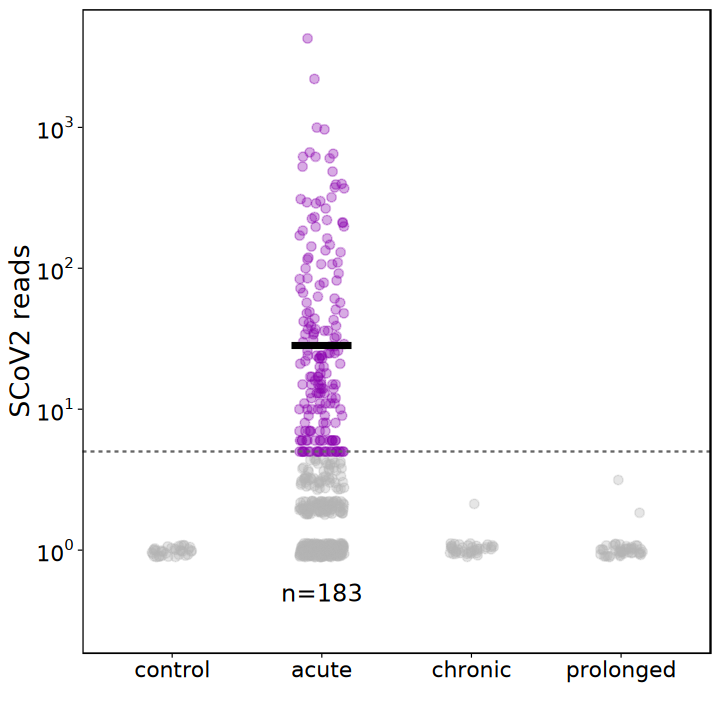

In [6]:
options(repr.plot.width = 6, repr.plot.height = 6, warn = -1)

min_val <- min(df$covid_reads[df$covid_reads > 0], na.rm = TRUE)

df_plot <- df %>%
    filter(covid_reads > 0) %>%
    mutate(
        condition  = factor(condition, levels = c("control", "akut", "chronic", "prolonged")),
        above_thr  = covid_reads >= 5
    )

n_labels <- df_plot %>%
    filter(above_thr) %>%
    group_by(condition) %>%
    summarise(n = n(), .groups = "drop") %>%
    mutate(y         = min_val * 0.5,
           condition = factor(condition, levels = c("control", "akut", "chronic", "prolonged")))

p <- ggplot(df_plot, aes(x = condition, y = covid_reads)) +
    geom_jitter(data = filter(df_plot, !above_thr),
                width = 0.15, size = 2, alpha = 0.33, color = "grey70") +
    geom_jitter(data = filter(df_plot, above_thr),
                aes(color = condition),
                width = 0.15, size = 2, alpha = 0.33) +
    stat_summary(data = filter(df_plot, above_thr),
                 aes(color = condition),
                 fun = mean, geom = "crossbar",
                 width = 0.4, color = "black", linewidth = 0.6) +
    geom_hline(yintercept = 5, linetype = "dashed", color = "grey40", linewidth = 0.5) +
    geom_text(data = n_labels,
              aes(x = condition, y = y, label = paste0("n=", n)),
              inherit.aes = FALSE, color = "black", size = 5) +
    scale_y_log10(labels = scales::label_log()) +
    scale_color_manual(values = c("control" = "#0E088D", "akut" = "#8A00AE",
                                  "chronic" = "#DD3978", "prolonged" = "#FF8F20")) +
    scale_x_discrete(labels = c("akut" = "acute")) +
    coord_cartesian(ylim = c(min_val * 0.3, NA)) +
    labs(x = "", y = "SCoV2 reads") +
    theme_linedraw() +
    theme(text = element_text(size = 16),
          panel.grid = element_blank(),
          legend.position = "none")

print(p)
ggsave("~/SP-COVID/analysis/COVID/out/plots/covid_reads_sce.svg",
       plot = p, device = svglite, width = 6, height = 6)

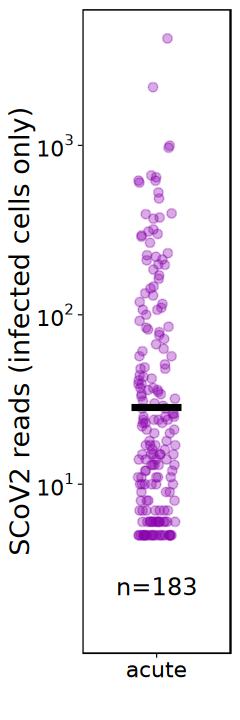

In [7]:
options(repr.plot.width = 2, repr.plot.height = 6, warn = -1)

df_pos <- df_plot %>% filter(above_thr)

n_labels_pos <- df_pos %>%
    group_by(condition) %>%
    summarise(n = n(), .groups = "drop") %>%
    mutate(y         = min(df_pos$covid_reads) * 0.5,
           condition = factor(condition, levels = c("control", "akut", "chronic", "prolonged")))

p_pos <- ggplot(df_pos, aes(x = condition, y = covid_reads, color = condition)) +
    geom_jitter(width = 0.15, size = 2, alpha = 0.33) +
    stat_summary(fun = mean, geom = "crossbar",
                 width = 0.4, color = "black", linewidth = 0.6) +
    geom_text(data = n_labels_pos,
              aes(x = condition, y = y, label = paste0("n=", n)),
              inherit.aes = FALSE, color = "black", size = 5) +
    scale_y_log10(labels = scales::label_log()) +
    scale_color_manual(values = c("control" = "#0E088D", "akut" = "#8A00AE",
                                  "chronic" = "#DD3978", "prolonged" = "#FF8F20")) +
    scale_x_discrete(labels = c("akut" = "acute")) +
    coord_cartesian(ylim = c(min(df_pos$covid_reads) * 0.3, NA)) +
    labs(x = "", y = "SCoV2 reads (infected cells only)") +
    theme_linedraw() +
    theme(text = element_text(size = 16),
          panel.grid = element_blank(),
          legend.position = "none")

print(p_pos)
ggsave("~/SP-COVID/analysis/COVID/out/plots/covid_reads_infected_sce.svg",
       plot = p_pos, device = svglite, width = 2, height = 6)

## Visium
### Expression across categories

In [8]:
spe_to_df <- function(spe, tissue_label) {
    cd <- as.data.frame(colData(spe))
    cd$x <- spatialCoords(spe)[, 1]
    cd$y <- spatialCoords(spe)[, 2]
    cd$tissue <- tissue_label
    cd
}

coldata_lung <- spe_to_df(spe_lung, "Lung")
coldata_ln <- spe_to_df(spe_ln,   "Lymph Node")

In [9]:
add_covid_info <- function(spe, df) {
    covid_genes <- grepl("^SCoV2_", rownames(spe))
    covid_reads <- Matrix::colSums(counts(spe)[covid_genes, , drop = FALSE])
    df$covid_reads <- covid_reads
    df <- df %>%
        mutate(infected = case_when(
            covid_reads >= 5 ~ "SCoV2_pos",
            covid_reads >  0 ~ "SCoV2_low",
            TRUE             ~ "SCoV2_neg"
        ))
    df
}

coldata_lung <- add_covid_info(spe_lung, coldata_lung)
coldata_ln   <- add_covid_info(spe_ln, coldata_ln)

cat("=== LUNG ===\n\n")
coldata_lung %>%
    group_by(disease_group) %>%
    summarise(n_infected = sum(covid_reads >= 5),
              n_total    = n(),
              .groups    = "drop") %>%
    mutate(fraction = round(n_infected / n_total, 2)) %>%
    print()

cat("\n")
print(table(coldata_lung$infected, coldata_lung$study_id))
cat("\n\n\n")
print(table(coldata_lung$infected, coldata_lung$annotation))
cat("\n\n\n")
by(coldata_lung$covid_reads[coldata_lung$covid_reads >= 5], list(coldata_lung$study_id[coldata_lung$covid_reads >= 5]), summary)
cat("\n\n\n")
by(coldata_lung$covid_reads[coldata_lung$covid_reads >= 5], list(coldata_lung$annotation[coldata_lung$covid_reads >= 5]), summary)

cat("\n=== LYMPH NODE ===\n\n")
coldata_ln %>%
    group_by(disease_group) %>%
    summarise(n_infected = sum(covid_reads >= 5),
              n_total    = n(),
              .groups    = "drop") %>%
    mutate(fraction = round(n_infected / n_total, 2)) %>%
    print()

cat("\n")
print(table(coldata_ln$infected, coldata_ln$study_id))
cat("\n\n\n")
print(table(coldata_ln$infected, coldata_ln$annotation))
cat("\n\n\n")
by(coldata_ln$covid_reads[coldata_ln$covid_reads >= 5], list(coldata_ln$study_id[coldata_ln$covid_reads >= 5]), summary)
cat("\n\n\n")
by(coldata_ln$covid_reads[coldata_ln$covid_reads >= 5], list(coldata_ln$annotation[coldata_ln$covid_reads >= 5]), summary)

=== LUNG ===

# A tibble: 4 × 4
  disease_group n_infected n_total fraction
  <chr>              <int>   <int>    <dbl>
1 acute               2284    6906     0.33
2 chronic                1    9589     0   
3 control                0    7471     0   
4 prolonged              0    9245     0   

           
            acute_case_1 acute_case_2 acute_case_3 chronic_case_1
  SCoV2_low         1008          486           84              9
  SCoV2_neg          373         2664            7           2881
  SCoV2_pos          496           27         1761              0
           
            chronic_case_2 chronic_case_4 control_case_1 control_case_2
  SCoV2_low            533              0              8              6
  SCoV2_neg           2352           3813           2817           2069
  SCoV2_pos              1              0              0              0
           
            control_case_3 prolonged_case_3 prolonged_case_4 prolonged_case_5
  SCoV2_low            125           

: acute_case_1
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  5.000   5.000   7.000   8.609   9.000 158.000 
------------------------------------------------------------ 
: acute_case_2
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   5.00    5.00    6.00   10.19   12.00   48.00 
------------------------------------------------------------ 
: acute_case_3
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
    5.0    12.0    17.0    26.9    25.0  3111.0 
------------------------------------------------------------ 
: chronic_case_2
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
      5       5       5       5       5       5 

: Alveolar epithelia
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   5.00   10.00   17.00   26.05   24.00  804.00 
------------------------------------------------------------ 
: Erythrocytes
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   5.00    7.00   10.00   15.87   17.00  153.00 
------------------------------------------------------------ 
: Fibroblasts
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   5.00    9.00   17.00   23.49   27.00  201.00 
------------------------------------------------------------ 
: Fibrovascular
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   5.00    8.00   14.00   19.59   24.00   99.00 
------------------------------------------------------------ 
: Macrophages
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   5.00   10.00   16.00   33.92   23.00 3111.00 
------------------------------------------------------------ 
: Plasma cells
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   5.00    9.00   16.00   25.41   25.75  574.00 
-------


=== LYMPH NODE ===

# A tibble: 4 × 4
  disease_group n_infected n_total fraction
  <chr>              <int>   <int>    <dbl>
1 acute                  0    2254        0
2 chronic                0    2891        0
3 control                0    4149        0
4 prolonged              0    2347        0

           
            acute_case_2 chronic_case_1 control_case_2 prolonged_case_5
  SCoV2_low            7              1              0                0
  SCoV2_neg         2247           2890           4149             2347



           
            Follicular Interfollicular Macrophages Plasma cells
  SCoV2_low          2               4           0            0
  SCoV2_neg        690            2302        1538         2542
           
            Smooth muscle/Myofibroblasts Unassigned Vascular
  SCoV2_low                            0          2        0
  SCoV2_neg                         1282       1616     1663








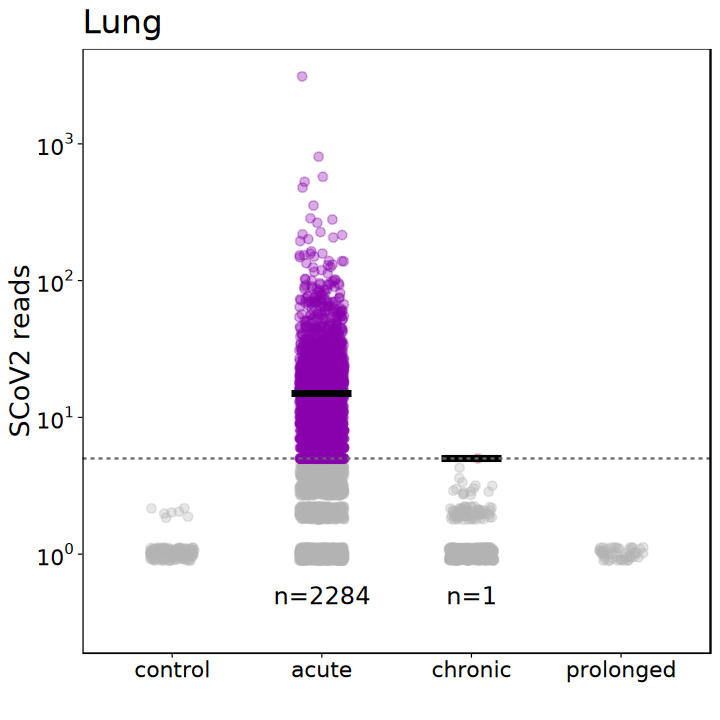

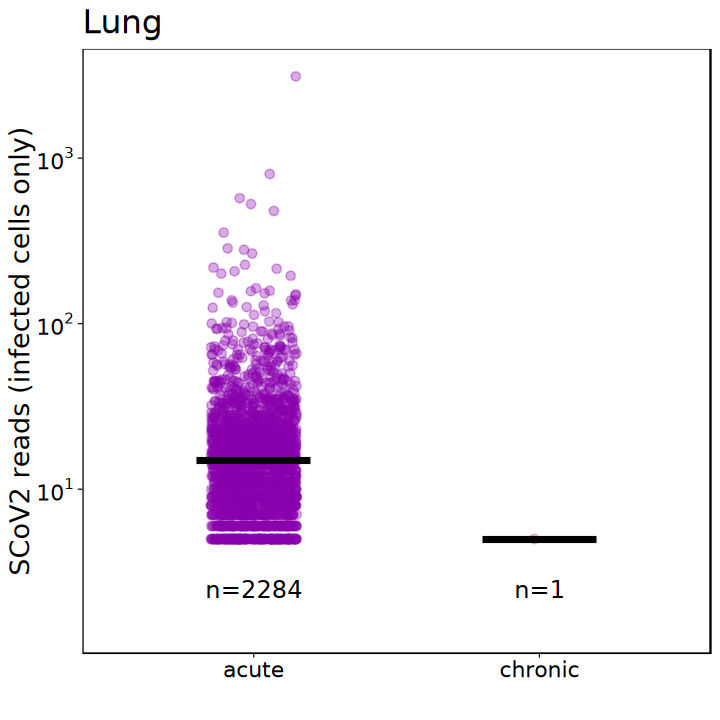

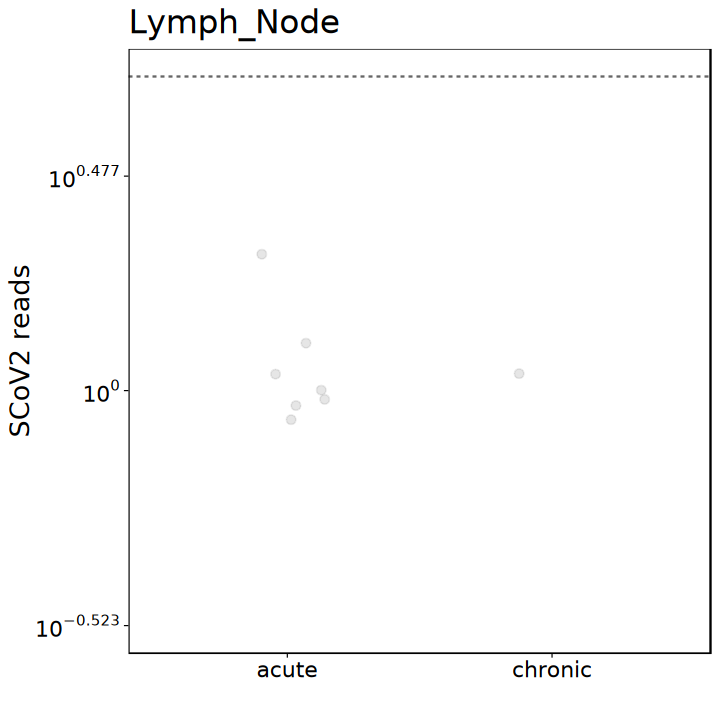

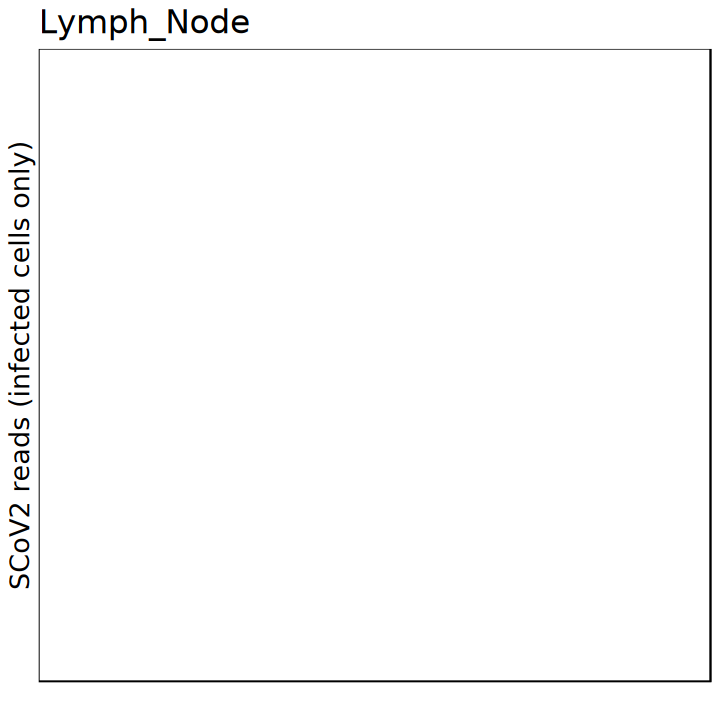

In [10]:
options(repr.plot.width = 6, repr.plot.height = 6, warn = -1)

plot_covid_reads <- function(df, tissue_label, out_dir = "~/SP-COVID/analysis/COVID/out/plots") {
    
    min_val <- min(df$covid_reads[df$covid_reads > 0], na.rm = TRUE)
    
    df_plot <- df %>%
        filter(covid_reads > 0) %>%
        mutate(
            disease_group = factor(disease_group, levels = c("control", "acute", "chronic", "prolonged")),
            above_thr = covid_reads >= 5
        )
    
    n_labels <- df_plot %>%
        filter(above_thr) %>%
        group_by(disease_group) %>%
        summarise(n = n(), .groups = "drop") %>%
        mutate(y         = min_val * 0.5,
               disease_group = factor(disease_group, levels = c("control", "acute", "chronic", "prolonged")))
        
    p <- ggplot(df_plot, aes(x = disease_group, y = covid_reads)) +
        geom_jitter(data = filter(df_plot, !above_thr),
                    width = 0.15, size = 2, alpha = 0.33, color = "grey70") +
        geom_jitter(data = filter(df_plot, above_thr),
                    aes(color = disease_group),
                    width = 0.15, size = 2, alpha = 0.33) +
        stat_summary(data = filter(df_plot, above_thr),
                     aes(color = disease_group),
                     fun = mean, geom = "crossbar",
                     width = 0.4, color = "black", linewidth = 0.6) +
        geom_hline(yintercept = 5, linetype = "dashed", color = "grey40", linewidth = 0.5) +
        geom_text(data = n_labels,
                  aes(x = disease_group, y = y, label = paste0("n=", n)),
                  inherit.aes = FALSE, color = "black", size = 5) +
        scale_y_log10(labels = scales::label_log()) +
        scale_color_manual(values = c("control" = "#0E088D", "acute" = "#8A00AE",
                                      "chronic" = "#DD3978", "prolonged" = "#FF8F20")) +
        scale_x_discrete(labels = c("akut" = "acute")) +
        coord_cartesian(ylim = c(min_val * 0.3, NA)) +
        labs(x = "", y = "SCoV2 reads", title = tissue_label) +
        theme_linedraw() +
        theme(text = element_text(size = 16),
              panel.grid = element_blank(),
              legend.position = "none")
    
    print(p)
    ggsave(file.path(out_dir, paste0("covid_reads_", tolower(gsub(" ", "_", tissue_label)), ".svg")),
           plot = p, device = svglite, width = 6, height = 6)
        
    df_pos <- df_plot %>% filter(above_thr)
    
    n_labels_pos <- df_pos %>%
        group_by(disease_group) %>%
        summarise(n = n(), .groups = "drop") %>%
        mutate(y         = min(df_pos$covid_reads) * 0.5,
               disease_group = factor(disease_group, levels = c("control", "acute", "chronic", "prolonged")))
    
    p_pos <- ggplot(df_pos, aes(x = disease_group, y = covid_reads, color = disease_group)) +
        geom_jitter(width = 0.15, size = 2, alpha = 0.33) +
        stat_summary(fun = mean, geom = "crossbar",
                     width = 0.4, color = "black", linewidth = 0.6) +
        geom_text(data = n_labels_pos,
                  aes(x = disease_group, y = y, label = paste0("n=", n)),
                  inherit.aes = FALSE, color = "black", size = 5) +
        scale_y_log10(labels = scales::label_log()) +
        scale_color_manual(values = c("control" = "#0E088D", "acute" = "#8A00AE",
                                      "chronic" = "#DD3978", "prolonged" = "#FF8F20")) +
        scale_x_discrete(labels = c("akut" = "acute")) +
        coord_cartesian(ylim = c(min(df_pos$covid_reads) * 0.3, NA)) +
        labs(x = "", y = "SCoV2 reads (infected cells only)", title = tissue_label) +
        theme_linedraw() +
        theme(text = element_text(size = 16),
              panel.grid = element_blank(),
              legend.position = "none")
    
    print(p_pos)
    ggsave(file.path(out_dir, paste0("covid_reads_infected_", tolower(gsub(" ", "_", tissue_label)), ".svg")),
           plot = p_pos, device = svglite, width = 2, height = 6)
}

plot_covid_reads(coldata_lung, "Lung")
plot_covid_reads(coldata_ln,   "Lymph_Node")

### Spatial plots

In [11]:
infection_class <- function(spe, round_digits = 2) {
    pct <- spe$subsets_SCoV2_percent
    infected <- pct[pct > 0]
    q <- quantile(infected, probs = c(0.33, 0.66), na.rm = TRUE)
    spe$infection_class <- dplyr::case_when(
        pct == 0 ~ "No infection",
        pct <= q[1] ~ paste0("Low (<", round(q[1], round_digits), "%)"),
        pct <= q[2] ~ paste0("Medium (", round(q[1], round_digits), "–", round(q[2], round_digits), "%)"),
        TRUE ~ paste0("High (>", round(q[2], round_digits), "%)"))
    spe$infection_class <- factor(spe$infection_class,
                                  levels = c("No infection",
                                             paste0("Low (<", round(q[1], round_digits), "%)"),
                                             paste0("Medium (", round(q[1], round_digits), "–", round(q[2], round_digits), "%)"),
                                             paste0("High (>", round(q[2], round_digits), "%)")))
    spe
}

spe_lung <- infection_class(spe_lung, round_digits = 2)
spe_ln <- infection_class(spe_ln, round_digits = 3)

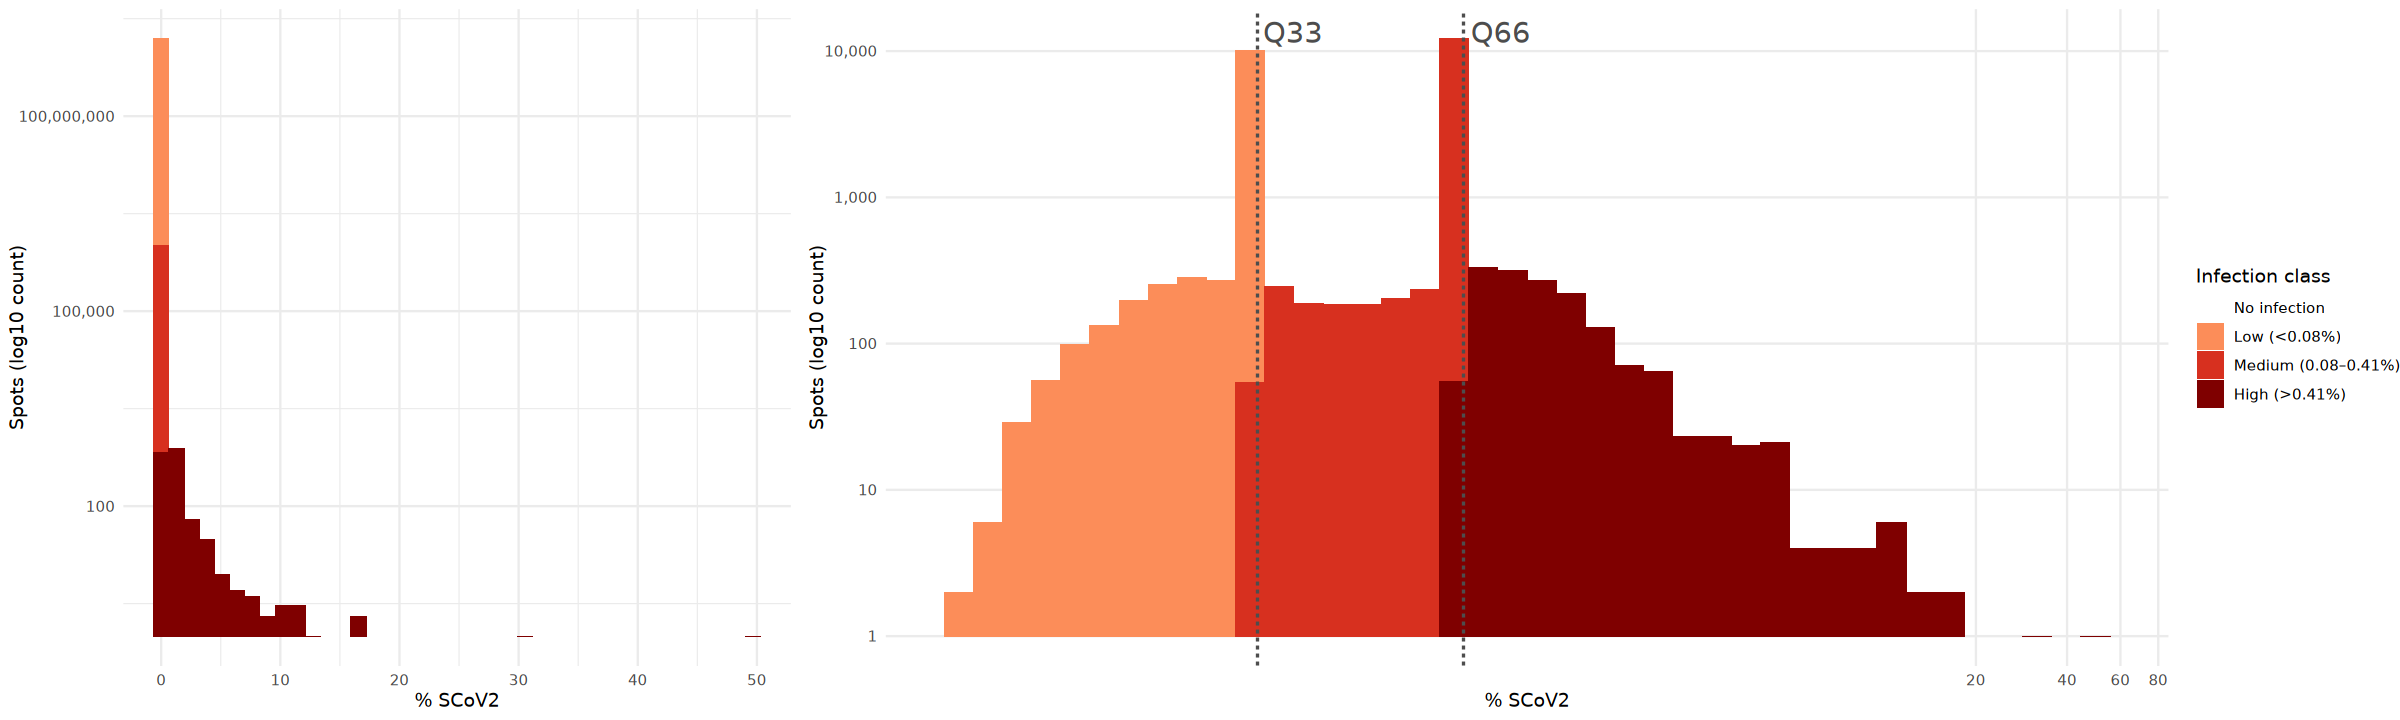

In [12]:
options(repr.plot.width = 20, repr.plot.height = 6, warn = -1)

plot_hist <- function(spe, round_digits = 2, bins = 40) {
    pct <- spe$subsets_SCoV2_percent
    infected <- pct[pct > 0]
    q <- quantile(infected, probs = c(0.33, 0.66), na.rm = TRUE)

    lvls <- levels(spe$infection_class)
    cols <- c("No infection" = "#d9d9d9", "Low" = "#fc8d59", "Medium" = "#d7301f", "High" = "#7f0000")
    palette <- setNames(cols[sub(" \\(.*", "", lvls)], lvls)

    p1 <- data.frame(pct = pct, class = spe$infection_class) %>%
    filter(., pct > 0) %>%

    ggplot(aes(x = pct, fill = class)) +
    geom_histogram(bins = bins, color = NA) +
    scale_fill_manual(values = palette, name = "Infection class",
                      limits = lvls, drop = FALSE) +
    scale_y_log10(labels = scales::comma) +
    labs(x = "% SCoV2", y = "Spots (log10 count)") +
    theme_minimal(base_size = 11) +
    theme(legend.position = "none")

    p2 <- data.frame(pct = pct, class = spe$infection_class) %>%
    filter(., pct > 0) %>%

    ggplot(aes(x = pct, fill = class)) +
    geom_histogram(bins = bins, color = NA) +
    geom_vline(xintercept = q[1], linetype = "dashed", color = "gray30", linewidth = 0.7) +
    geom_vline(xintercept = q[2], linetype = "dashed", color = "gray30", linewidth = 0.7) +
    annotate("text", x = q[1], y = 10000, vjust = -0.4, hjust = -0.1, size = 6, color = "gray30", label = "Q33") +
    annotate("text", x = q[2], y = 10000, vjust = -0.4, hjust = -0.1, size = 6, color = "gray30", label = "Q66 ") +
    scale_fill_manual(values = palette, name = "Infection class", limits = lvls, drop = FALSE) +
    scale_x_continuous(trans = scales::pseudo_log_trans(sigma = 1e-04)) +
    scale_y_log10(labels = scales::comma) +
    labs(x = "% SCoV2", y = "Spots (log10 count)") +
    theme_minimal(base_size = 11) +
    theme(legend.position = "right", panel.grid.minor = element_blank())
    
    plot_grid(p1, p2, ncol = 2, rel_widths = c(1, 2))
}

plot_hist(spe_lung)

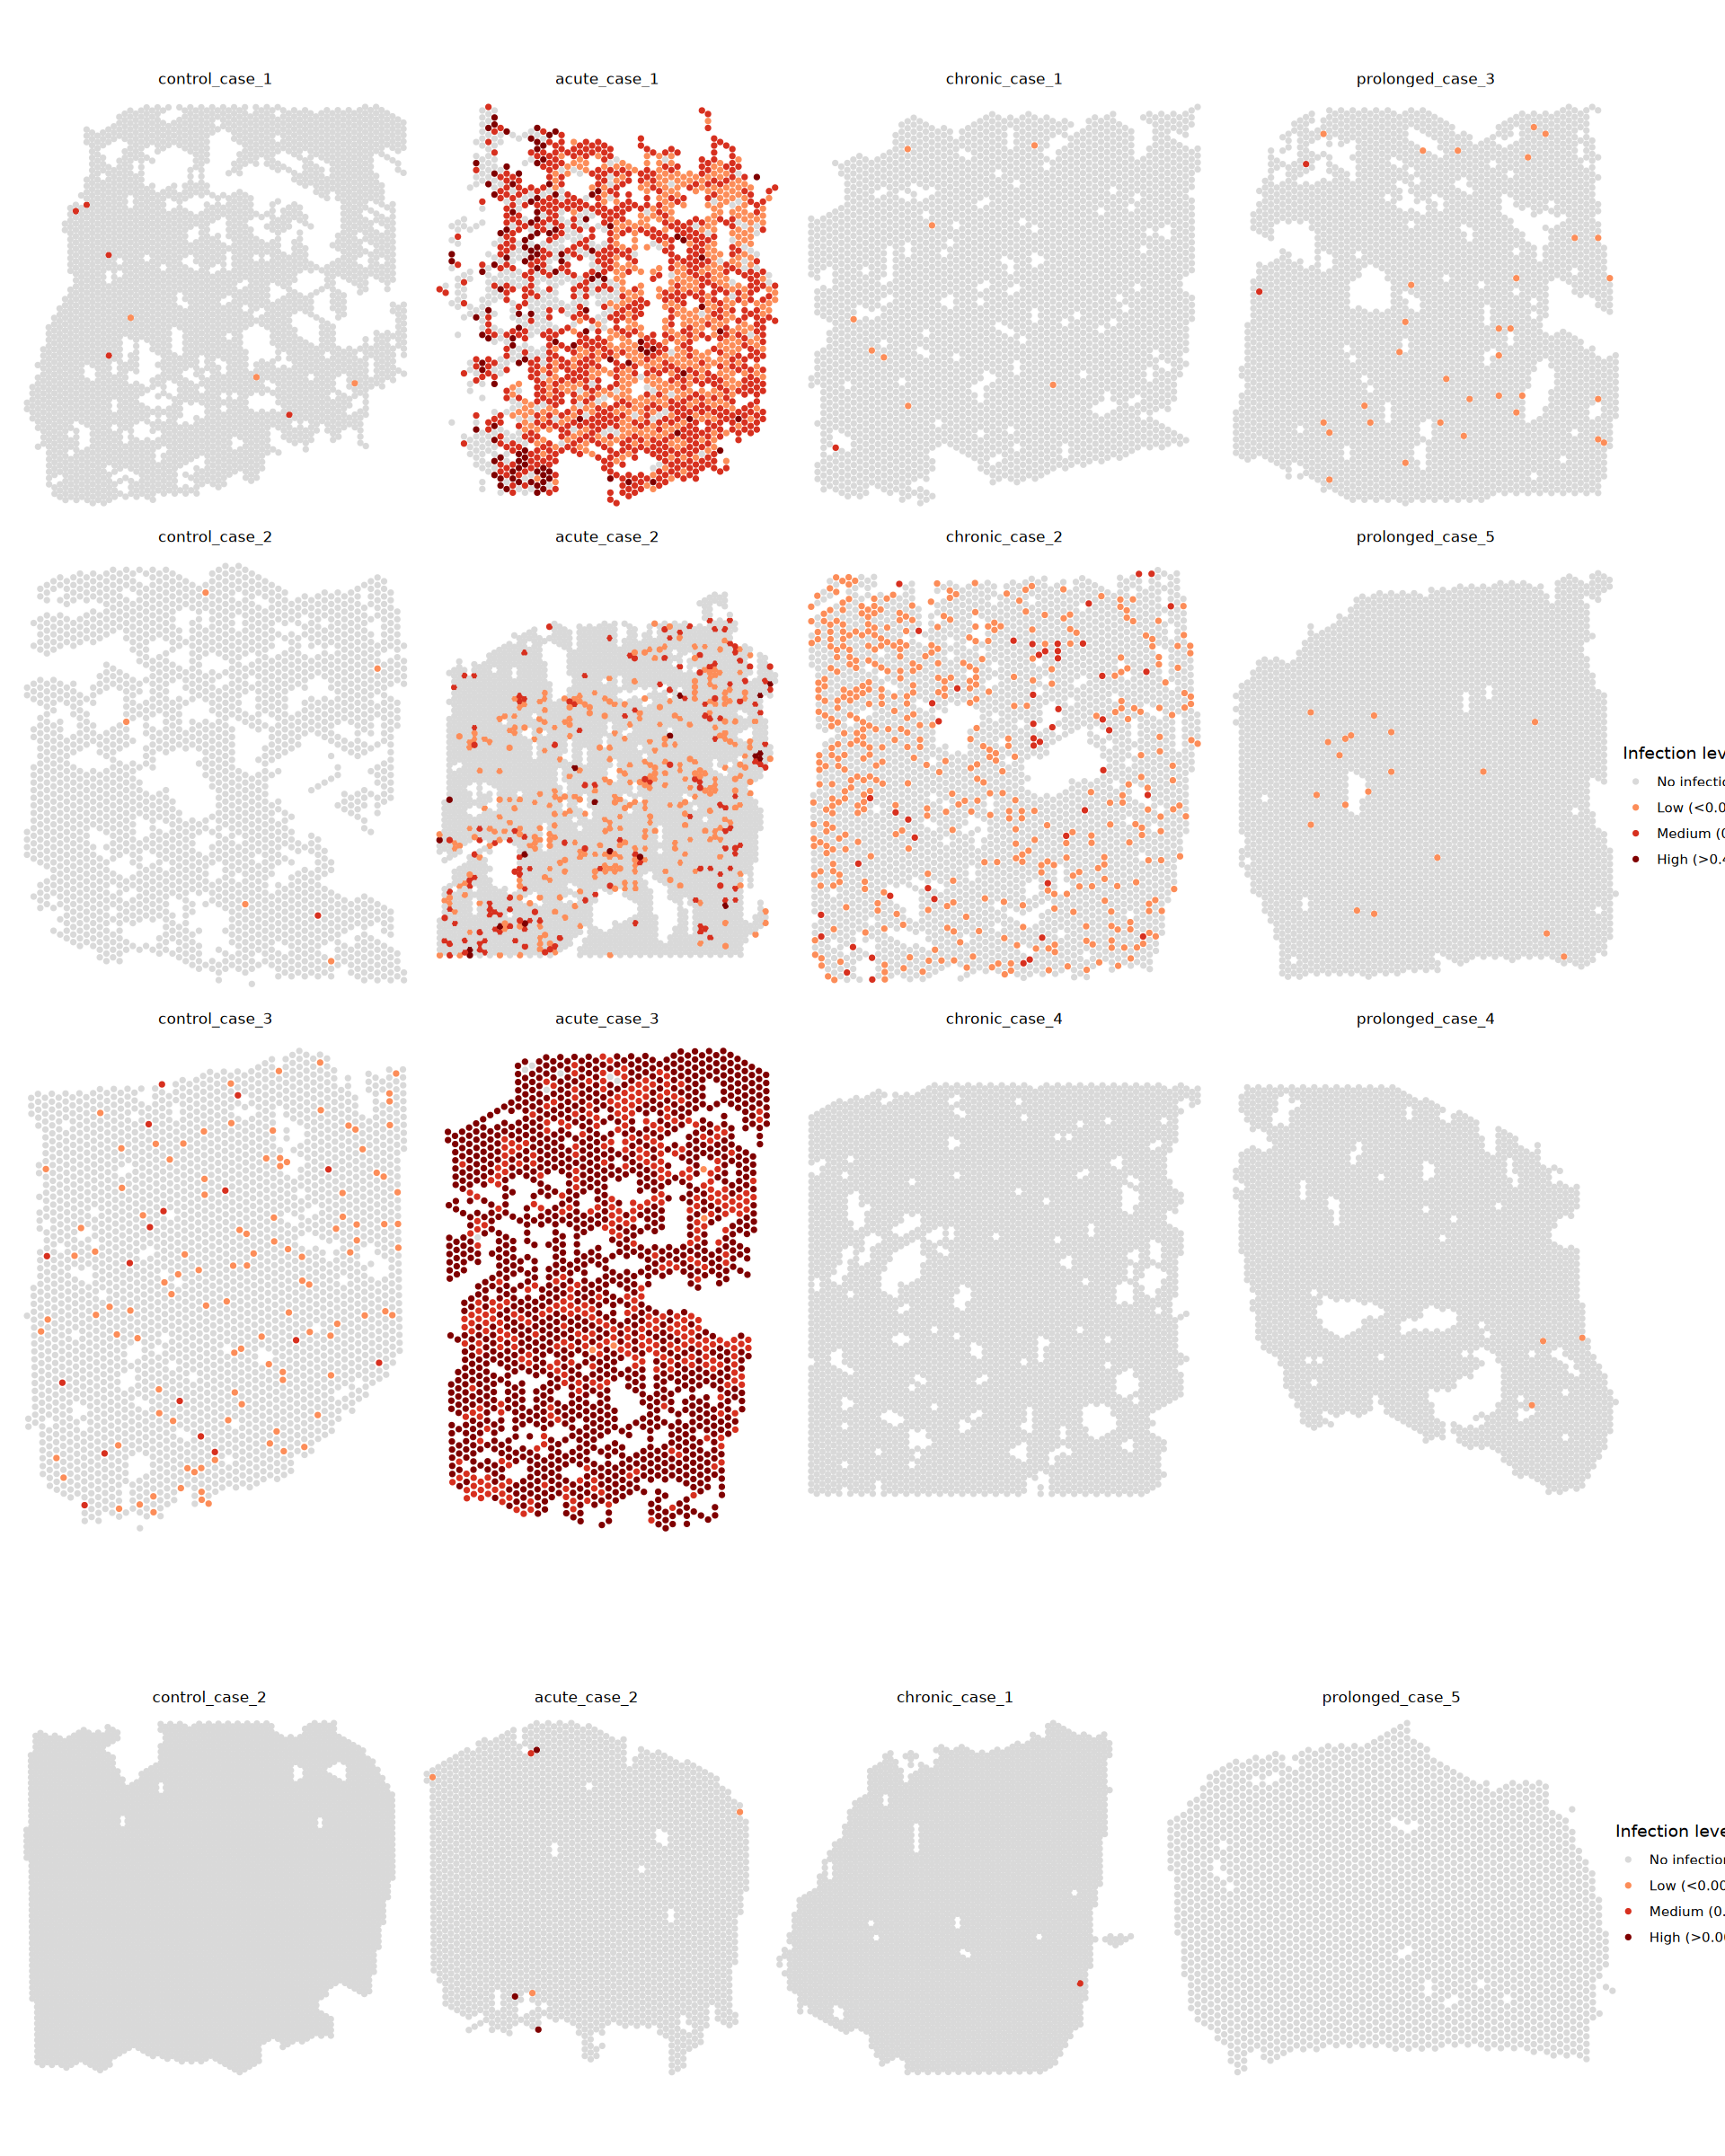

In [13]:
options(repr.plot.width = 16, repr.plot.height = 20, warn = -1)

plot_spatial_categorical <- function(spe, nrow, legend_id = "acute_case_2") {
    lvls <- levels(spe$infection_class)
    cols <- c("No infection" = "#d9d9d9", "Low" = "#fc8d59", "Medium" = "#d7301f", "High" = "#7f0000")
    palette <- setNames(cols[sub(" \\(.*", "", lvls)], lvls)
    
    legend_spe <- spe[, spe$study_id == legend_id]
    legend_spe$infection_class <- factor(legend_spe$infection_class, levels = lvls)
    xy <- spatialCoords(legend_spe)
    legend_spe$x <- xy[, 1]
    legend_spe$y <- xy[, 2]

    shared_legend <- get_legend(ggcells(legend_spe, aes(x, y, color = infection_class)) +
                                geom_point(size = 1) +
                                scale_color_manual(values = palette, name = "Infection level",
                                                   limits = lvls, drop = FALSE) +
                                theme_void() +
                                theme(legend.position  = "right",
                                      legend.box.margin = margin(l = 30)))

    lapply(unique(spe$study_id), function(id) {
      sub_spe <- spe[, spe$study_id == id]
      xy <- spatialCoords(sub_spe)
      sub_spe$x <- xy[, 1]
      sub_spe$y <- xy[, 2]
      sub_spe$infection_class <- factor(sub_spe$infection_class, levels = lvls)

      ggcells(sub_spe, aes(x, y, color = infection_class)) +
      geom_point(size = 1) +
      scale_color_manual(values = palette, name = "Infection level",
                         limits = lvls, drop = FALSE) +
      scale_y_reverse() +
      coord_fixed() +
      theme_void() +
      ggtitle(id) +
      theme(plot.title = element_text(hjust = 0.5, size = 10),
            legend.position = "none")
  }) %>%
    wrap_plots(., nrow = nrow, ncol = 4, byrow = FALSE) %>%
    plot_grid(., shared_legend, ncol = 2, rel_widths = c(20, 1))
}

p <- plot_grid(plot_spatial_categorical(spe_lung, nrow = 3), plot_spatial_categorical(spe_ln, nrow = 1), ncol = 1, rel_heights = c(3, 1))
ggsave("~/SP-COVID/analysis/COVID/out/plots/spatial_cov_categorical.svg", plot = p, device = svglite, width = 16, height = 20)
print(p)

### Percentage of infected spots

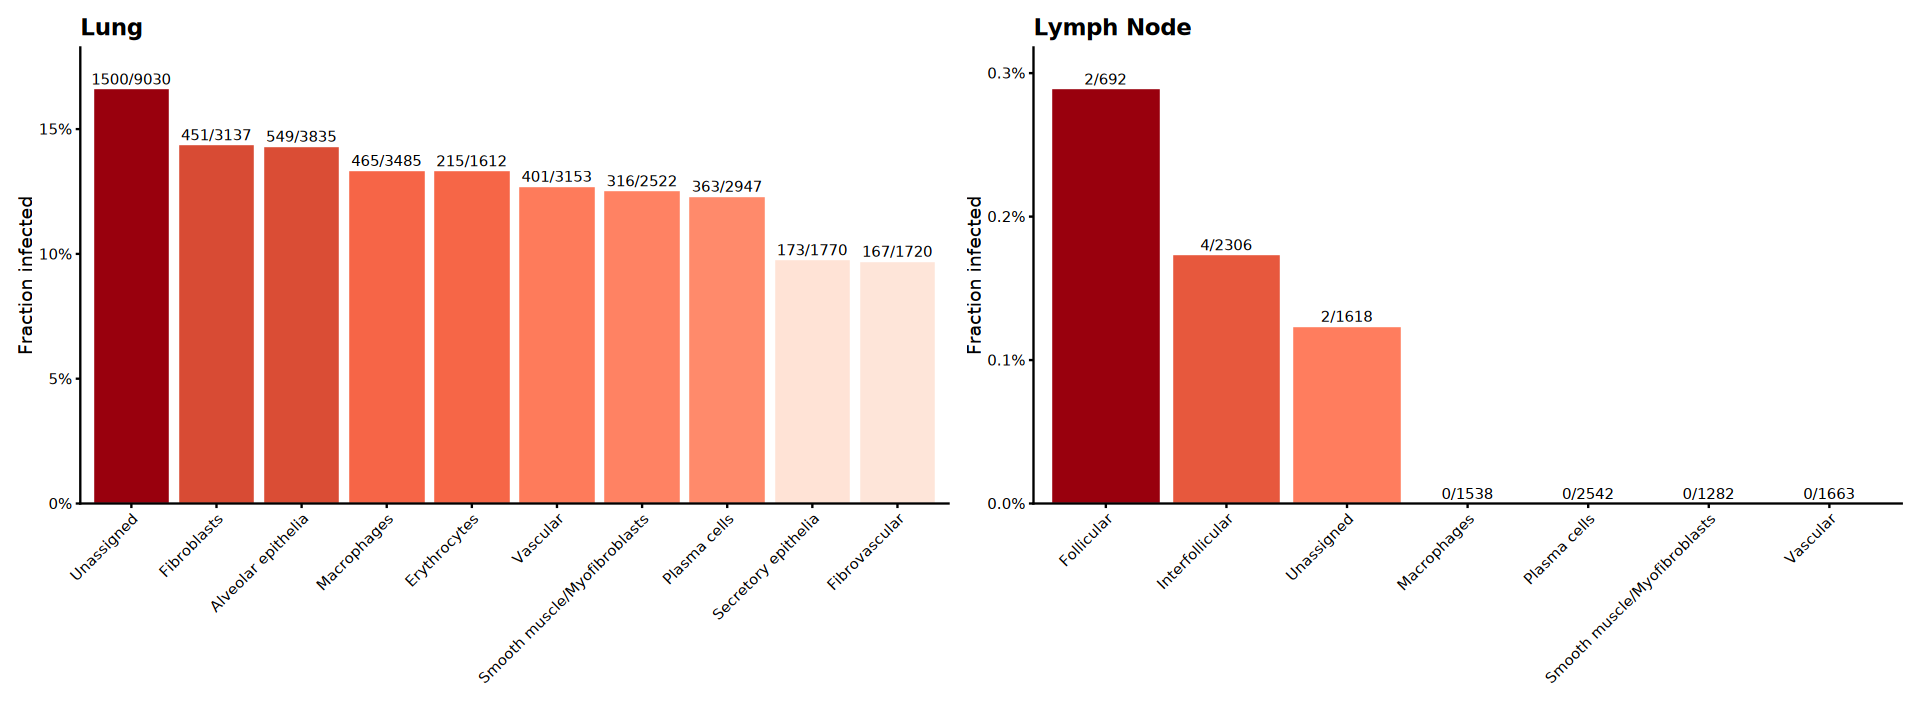

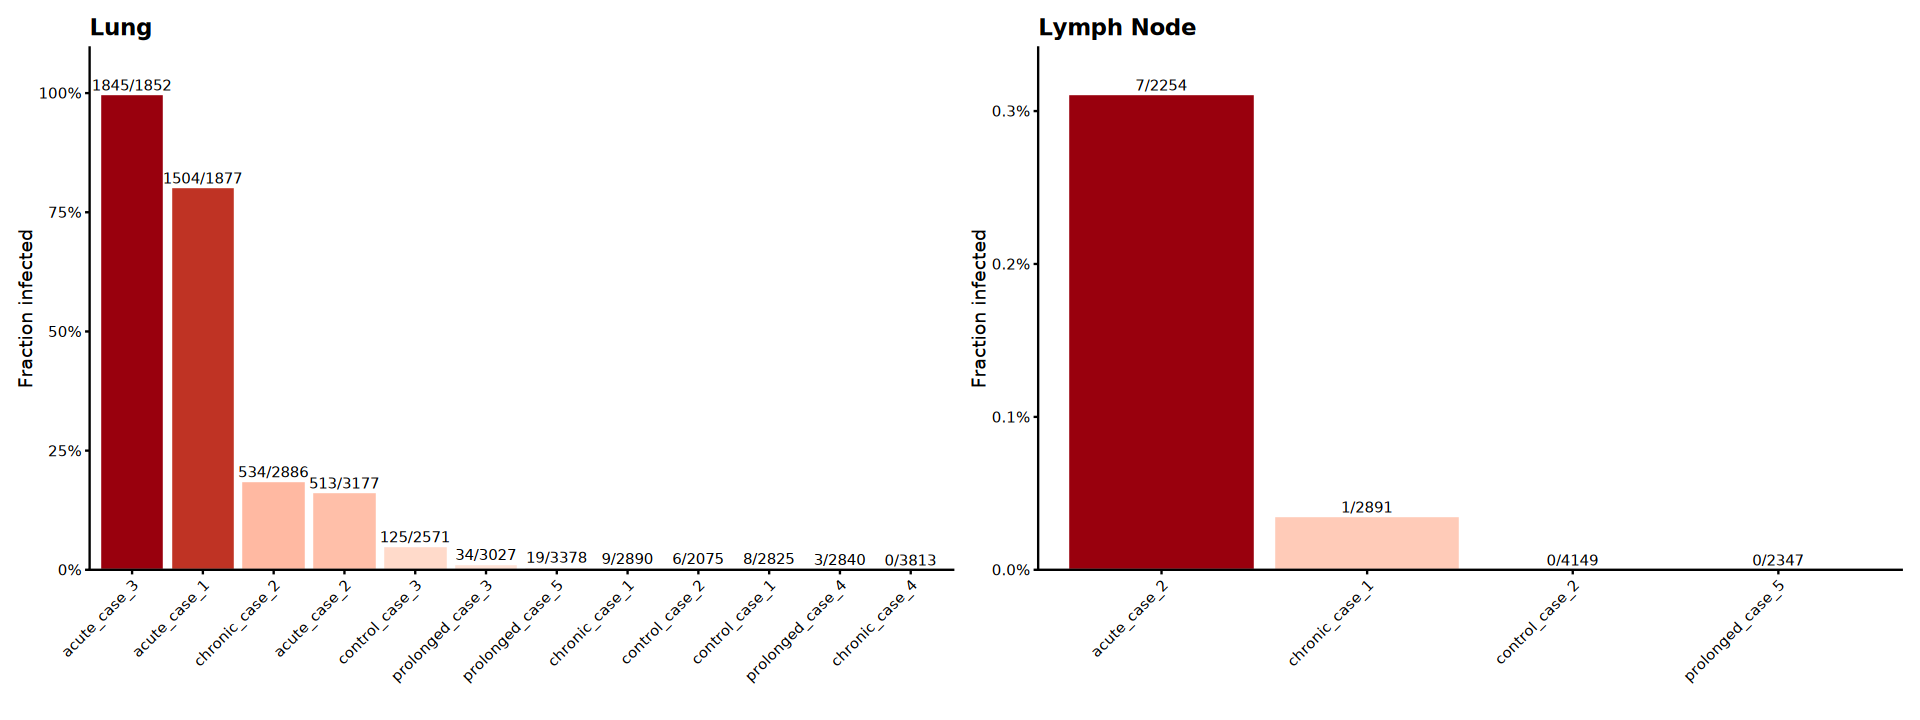

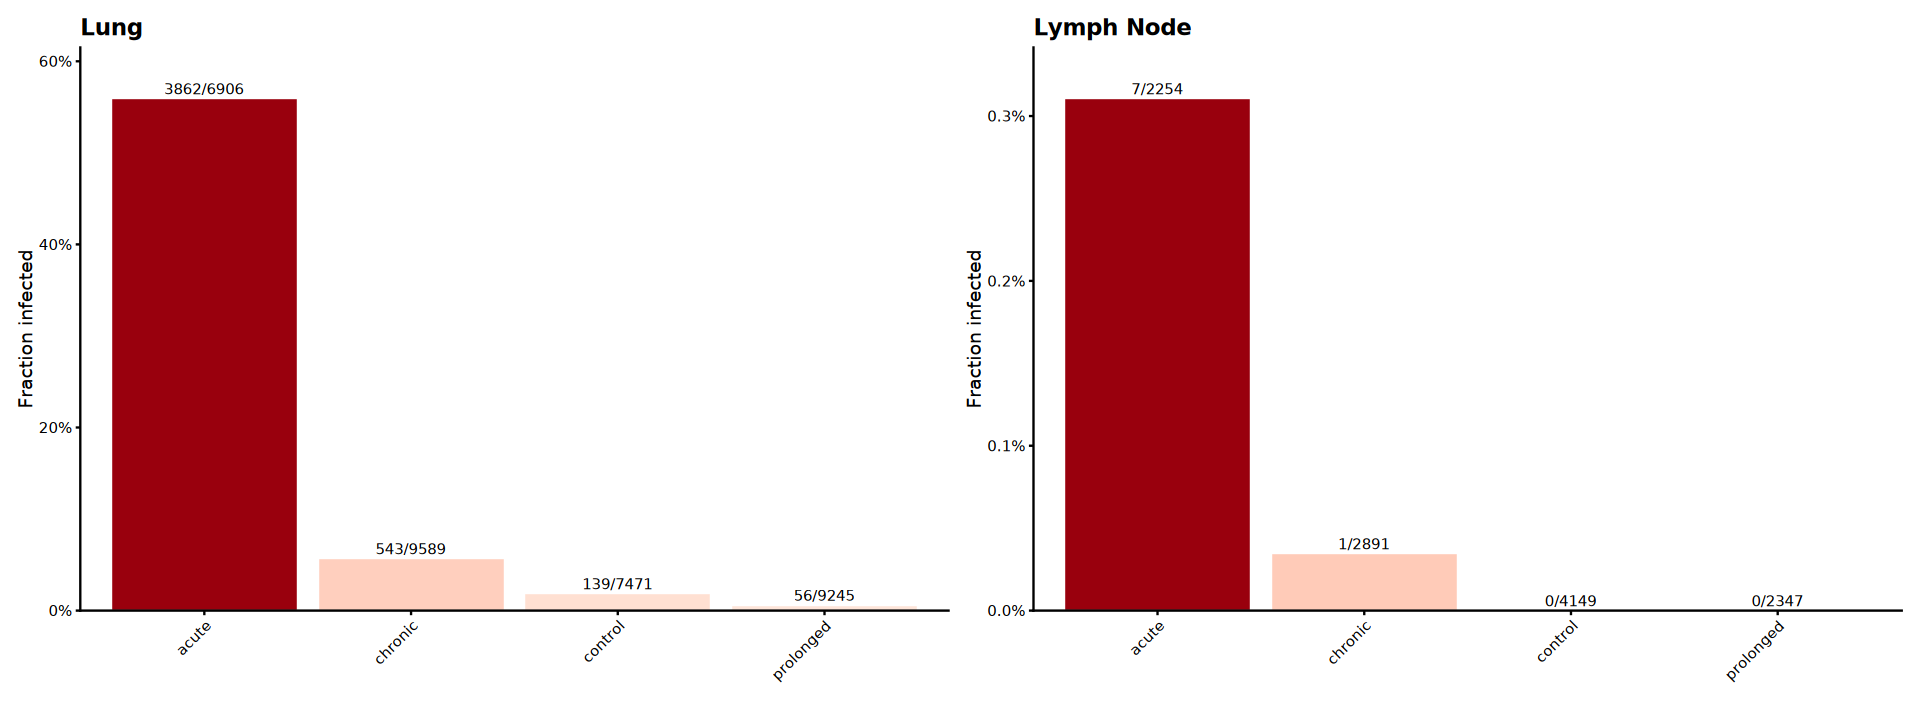

In [14]:
options(repr.plot.width = 16, repr.plot.height = 6, warn = -1)
plot_fraction <- function(spe, tissue_label, col, threshold = 0) {
  df <- data.frame(
    grp = colData(spe)[[col]],
    infected = spe$subsets_SCoV2_percent > threshold
  ) %>%
    filter(!is.na(grp)) %>%
    group_by(grp) %>%
    summarise(
      n_total = n(),
      n_infected = sum(infected),
      frac = n_infected / n_total
    ) %>%
    arrange(desc(frac)) %>%
    mutate(grp = factor(grp, levels = grp))  

  ggplot(df, aes(x = grp, y = frac, fill = frac)) +
    geom_col(colour = "white", linewidth = 0.3) +
    geom_text(aes(label = paste0(n_infected, "/", n_total)),
              vjust = -0.4, size = 3) +
    scale_fill_gradientn(colours = c("#fee5d9", "#fb6a4a", "#99000d"),
                         guide = "none") +
    scale_y_continuous(labels = scales::percent_format(),
                       expand = expansion(mult = c(0, 0.1))) +
    labs(title = tissue_label, x = "", y = "Fraction infected") +
    theme_classic(base_size = 11) +
    theme(
      axis.text.x = element_text(angle = 45, hjust = 1),
      plot.title  = element_text(face = "bold")
    )
}

p <- plot_fraction(spe_lung, "Lung", "annotation") | plot_fraction(spe_ln, "Lymph Node", "annotation")
ggsave("~/SP-COVID/analysis/COVID/out/plots/barplot_domain_fractioncov.svg", plot = p, device = svglite, width = 16, height = 6)
print(p)

p <- plot_fraction(spe_lung, "Lung", "study_id") | plot_fraction(spe_ln, "Lymph Node", "study_id")
ggsave("~/SP-COVID/analysis/COVID/out/plots/barplot_case_fractioncov.svg", plot = p, device = svglite, width = 16, height = 6)
print(p)

p <- plot_fraction(spe_lung, "Lung", "disease_group") | plot_fraction(spe_ln, "Lymph Node", "disease_group")
ggsave("~/SP-COVID/analysis/COVID/out/plots/barplot_stage_fractioncov.svg", plot = p, device = svglite, width = 16, height = 6)
print(p)

# Correlation of deconvolution weights and SCov2 %

In [15]:
build_deconv <- function(spe, mat_filtered) {
  viral <- colData(spe) %>%
    as.data.frame() %>%
    select(subsets_SCoV2_percent) %>%
    tibble::rownames_to_column("spot_id")
  
  deconv <- as.data.frame(mat_filtered) %>%
    tibble::rownames_to_column("spot_id")
  
  inner_join(viral, deconv, by = "spot_id")
}

deconv_lung <- build_deconv(spe_lung, mat_filtered_lung)
deconv_ln   <- build_deconv(spe_ln,   mat_filtered_ln)

In [16]:
options(repr.plot.width = 14, repr.plot.height = 8)
make_heatmap <- function(df, spe, tissue_name, n_spots = NA) {

  cell_types <- setdiff(colnames(df), c("spot_id", "subsets_SCoV2_percent"))

  viral_pos <- df %>%
    filter(subsets_SCoV2_percent > 0) %>%
    arrange(desc(subsets_SCoV2_percent))

  if (!is.na(n_spots)) viral_pos <- head(viral_pos, n_spots)

  mat <- t(as.matrix(viral_pos[, cell_types]))
  colnames(mat) <- viral_pos$spot_id
  mat <- mat[rowSums(mat > 0, na.rm = TRUE) > 0, , drop = FALSE]

  viral_vec <- viral_pos$subsets_SCoV2_percent
  vmin <- min(viral_vec[viral_vec > 0], na.rm = TRUE)
  vmax <- max(viral_vec, na.rm = TRUE)

  breaks_original <- c(0, 10^seq(floor(log10(vmin)), ceiling(log10(vmax)), by = 1))
  trans_fun <- function(x) sign(x) * log1p(abs(x) / 1e-4)

  viral_vec_log <- trans_fun(viral_vec)
  breaks_trans <- trans_fun(breaks_original)

  top_anno <- HeatmapAnnotation(
    `SCoV2 %` = anno_barplot(
      viral_vec_log,
      gp = gpar(fill = ifelse(viral_vec > 0, "#E31A1C", "grey80"), col = NA),
      height = unit(2, "cm"),
      ylim = range(breaks_trans),
      axis_param = list(
        at = breaks_trans,
        labels = as.character(breaks_original),
        gp = gpar(fontsize = 8)
      )
    ),
    annotation_name_gp = gpar(fontsize = 9),
    show_legend = FALSE
  )

  col_fun <- colorRamp2(c(0, 0.5, 1), c("#F7F7F7", "#4393C3", "#053061"))

  ht <- Heatmap(
    mat,
    name = "Proportion",
    col = col_fun,
    top_annotation = top_anno,
    cluster_columns = FALSE,
    cluster_rows = TRUE,
    show_column_names = FALSE,
    row_names_gp = gpar(fontsize = 9),
    row_names_side = "left",
    column_title = sprintf("%s — spots sorted by SCoV2 %% (n=%d)", tissue_name, ncol(mat)),
    column_title_gp = gpar(fontsize = 11, fontface = "bold"),
    use_raster = FALSE
  )

  return(ht)
}

agg_record_32f7c39fe9bef 
                       2

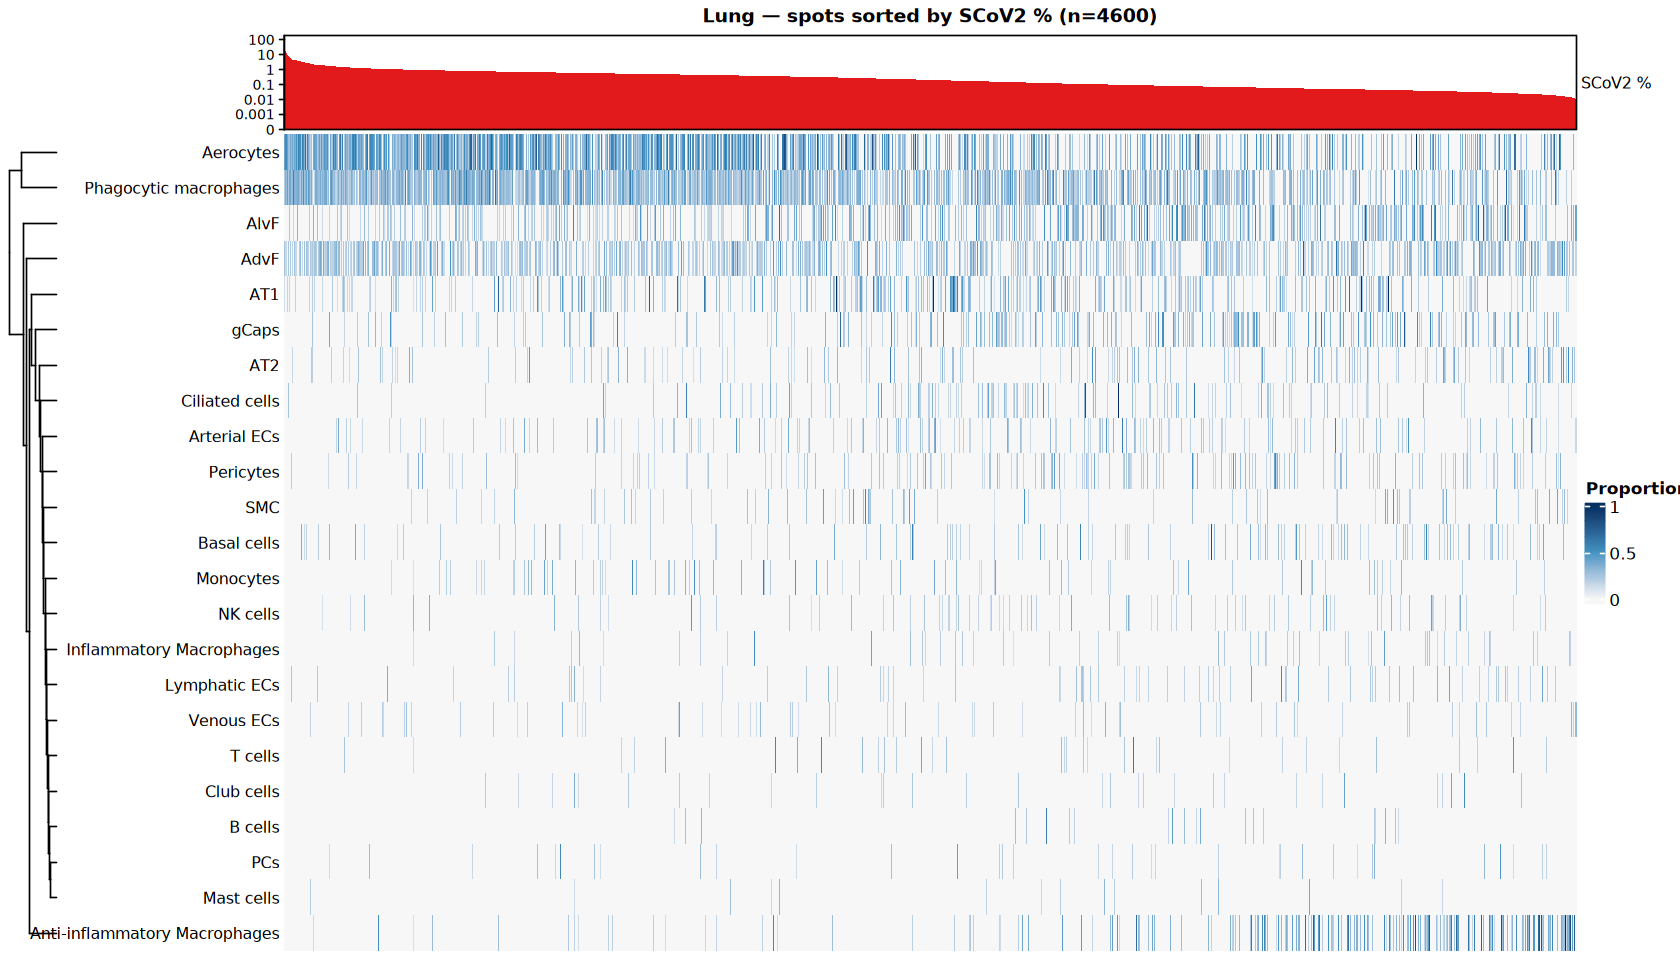

In [17]:
make_heatmap(deconv_lung, spe_lung, "Lung")
svglite::svglite("~/SP-COVID/analysis/COVID/out/plots/heatmap_covid_deconv.svg",
                 width = 14, height = 8)
draw(make_heatmap(deconv_lung, spe_lung, "Lung"))
dev.off()

In [18]:
compute_cors <- function(df) {
  cell_types <- setdiff(colnames(df), c("spot_id", "subsets_SCoV2_percent"))
  viral_pos <- df %>% filter(subsets_SCoV2_percent > 0)
  
  variable_types <- cell_types[sapply(cell_types, function(ct) {
    sd(viral_pos[[ct]], na.rm = TRUE) > 0
  })]
  
  viral_pos %>%
    summarise(across(all_of(variable_types), 
      ~ cor(., subsets_SCoV2_percent, method = "spearman", use = "complete.obs"))) %>%
    pivot_longer(everything(), names_to = "cell_type", values_to = "r") %>%
    column_to_rownames("cell_type") %>%
    as.matrix()
}

make_cor_heatmap <- function(mat) {
    Heatmap(mat, name = "Spearman r",
    col = colorRamp2(c(-1, 0, 1), c("#4393C3", "#F7F7F7", "#E31A1C")),
    cluster_rows = TRUE, cluster_columns = FALSE, 
    show_column_names = FALSE, show_row_dend = FALSE,
    row_names_gp = gpar(fontsize = 9), row_names_side = "left",
    column_title_gp = gpar(fontsize = 11, fontface = "bold"),
    width = unit(1.5, "cm"),         
    cell_fun = function(j, i, x, y, width, height, fill) {
      grid.text(sprintf("%.2f", mat[i, j]), x, y,
                gp = gpar(fontsize = 8))
    },
    na_col = "grey90",
    heatmap_legend_param = list(
      title_gp = gpar(fontsize = 9),
      labels_gp = gpar(fontsize = 8),
      legend_height = unit(3, "cm")
    )
  )
}

In [19]:
compute_cors(deconv_lung)

,r
AdvF,0.06079127
Aerocytes,0.47568376
AlvF,-0.14389674
Anti-inflammatory Macrophages,-0.37877835
Arterial ECs,-0.03546149
AT1,-0.06249960
AT2,-0.09696400
B cells,-0.05885576
Basal cells,-0.10607946
Ciliated cells,-0.10711721


agg_record_32f7c1bdbd6d0 
                       2

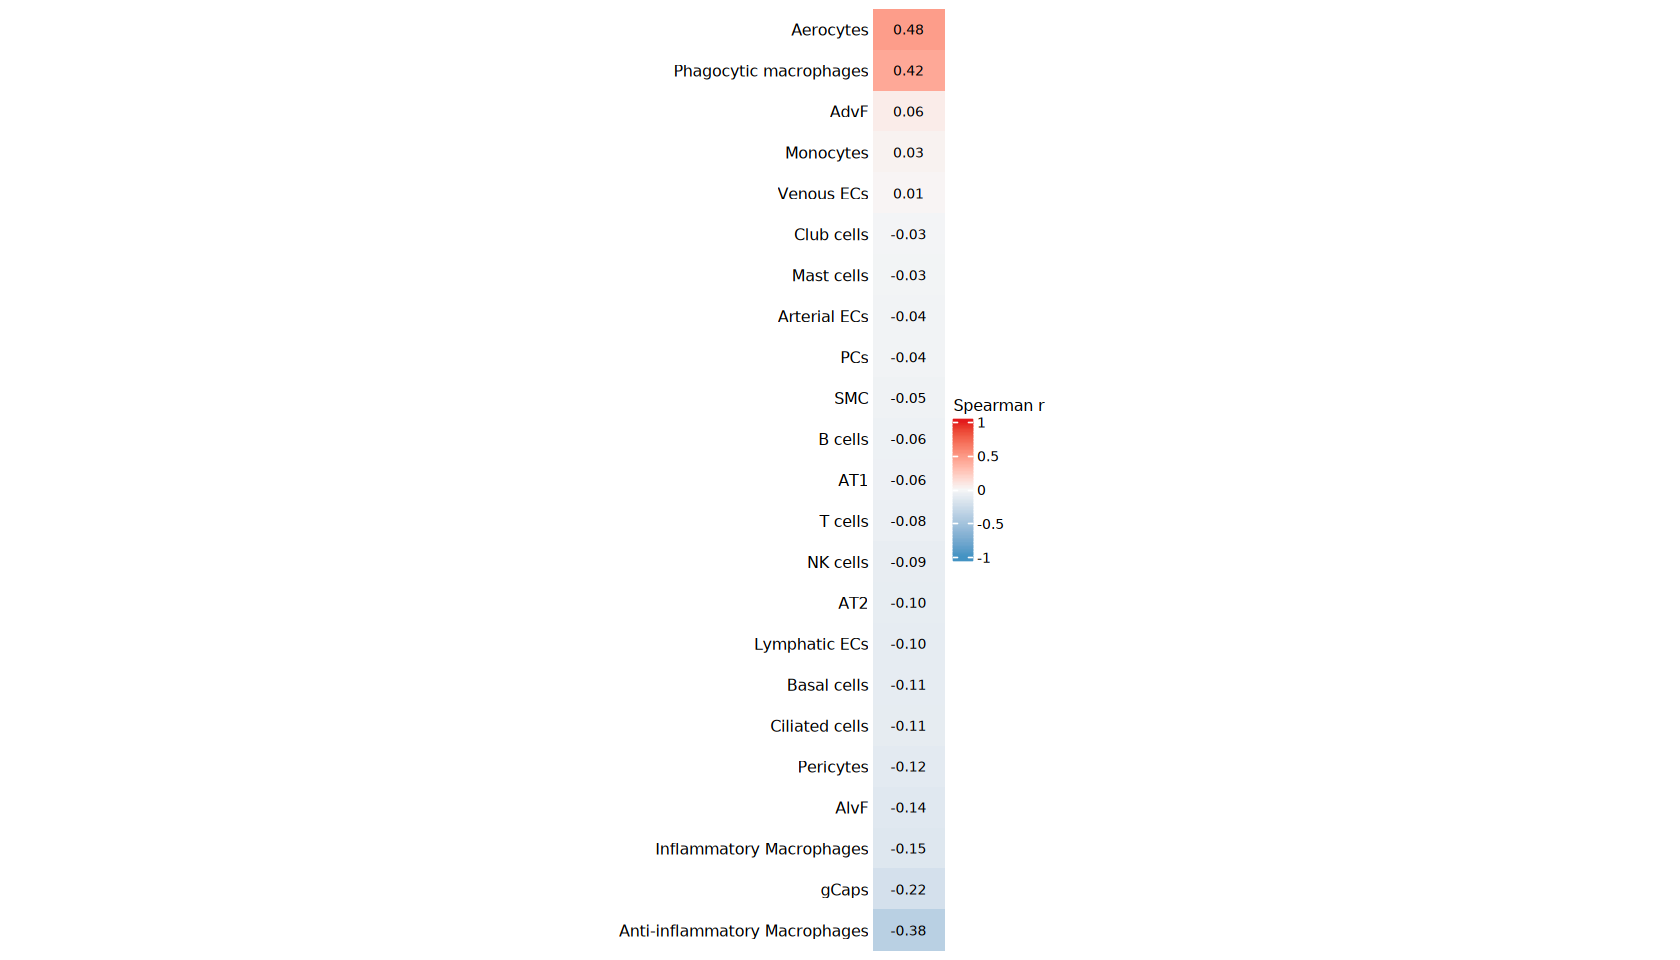

In [20]:
make_cor_heatmap(compute_cors(deconv_lung))
svglite::svglite("~/SP-COVID/analysis/COVID/out/plots/corr_covid_deconv.svg", width = 14, height = 8)
draw(make_cor_heatmap(compute_cors(deconv_lung)))
dev.off()

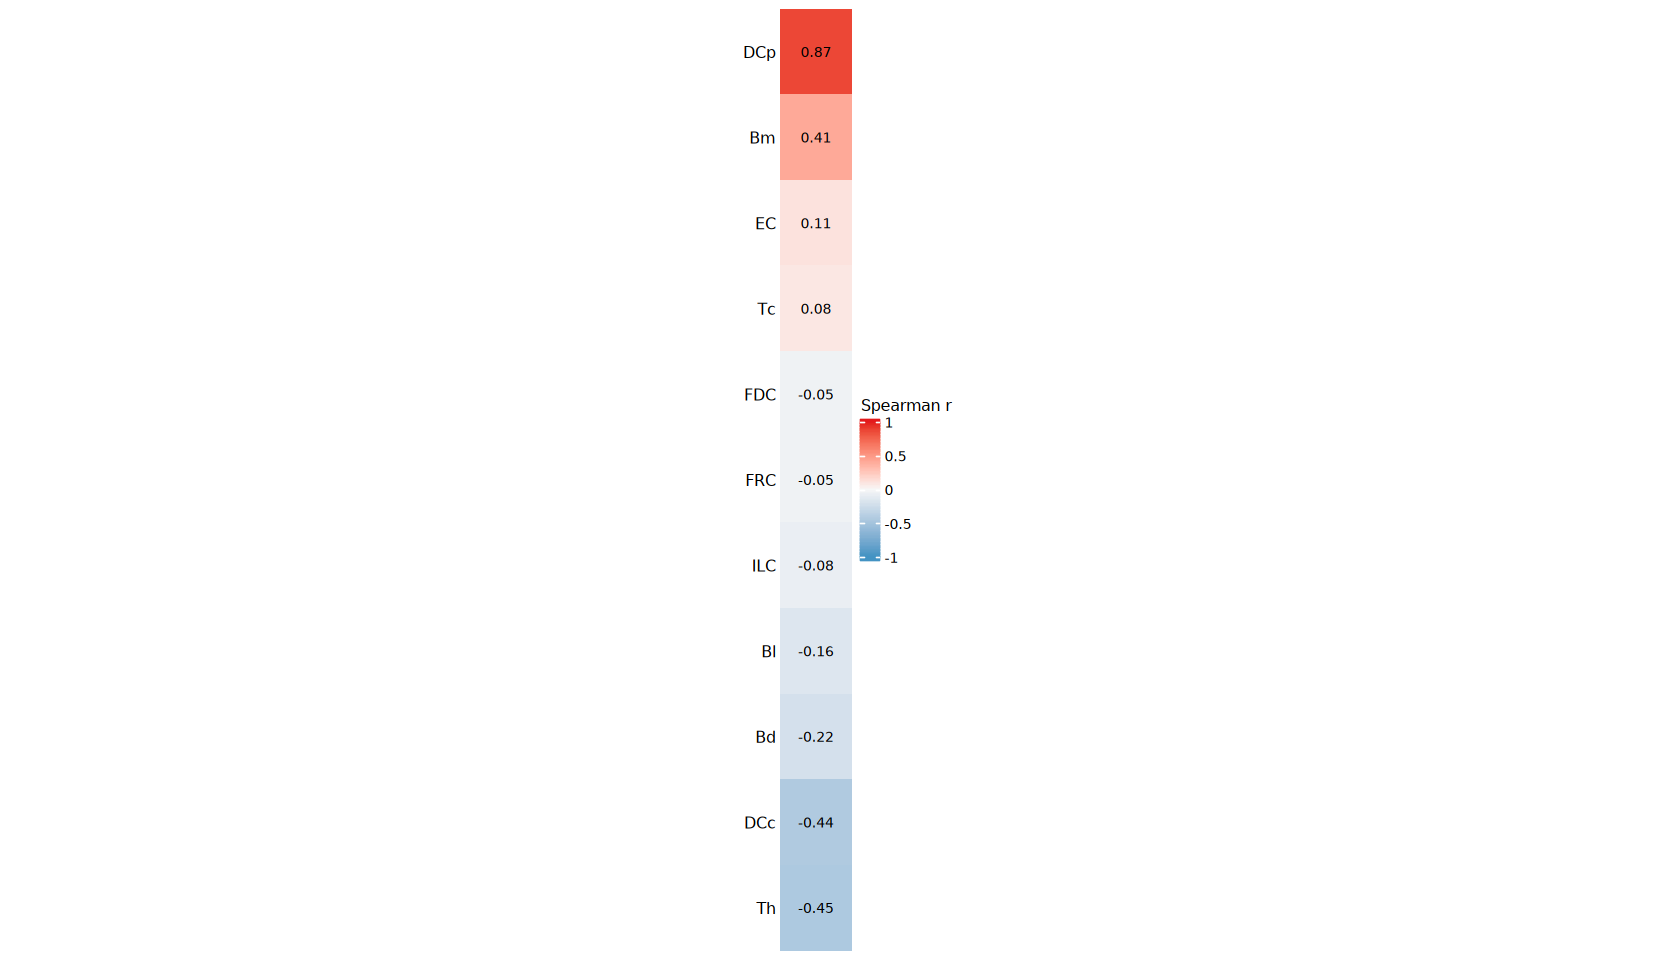

In [21]:
make_cor_heatmap(compute_cors(deconv_ln))

# Session information

In [22]:
sessionInfo()

R version 4.5.2 (2025-10-31)
Platform: x86_64-conda-linux-gnu
Running under: CentOS Linux 7 (Core)

Matrix products: default
BLAS/LAPACK: /home/groups/singlecell/cvicente/miniconda3/envs/COVID/lib/libopenblasp-r0.3.30.so;  LAPACK version 3.12.0

locale:
 [1] LC_CTYPE=en_US.UTF-8       LC_NUMERIC=C              
 [3] LC_TIME=en_US.UTF-8        LC_COLLATE=en_US.UTF-8    
 [5] LC_MONETARY=en_US.UTF-8    LC_MESSAGES=en_US.UTF-8   
 [7] LC_PAPER=en_US.UTF-8       LC_NAME=C                 
 [9] LC_ADDRESS=C               LC_TELEPHONE=C            
[11] LC_MEASUREMENT=en_US.UTF-8 LC_IDENTIFICATION=C       

time zone: Europe/Madrid
tzcode source: system (glibc)

attached base packages:
[1] grid      stats4    stats     graphics  grDevices utils     datasets 
[8] methods   base     

other attached packages:
 [1] svglite_2.2.2               circlize_0.4.17            
 [3] ComplexHeatmap_2.26.1       scran_1.38.0               
 [5] viridis_0.6.5               viridisLite_0.4.3          
 [7]